## EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import gc
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")

plt.rcParams.update({"figure.figsize": (12, 5), "figure.dpi": 100, "axes.titlesize": 14})

In [3]:
DATA_PATH = "../train-test.csv"
VAL_PATH = "../validation.csv"
DEC_PATH = "../december-chart-inputs.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
val = pd.read_csv(VAL_PATH, parse_dates=["date"])
dec = pd.read_csv(DEC_PATH, parse_dates=["date"])

print(f"Train shape: {df.shape}")
print(f"Validation shape: {val.shape}")
print(f"December shape: {dec.shape}")

Train shape: (48000, 14)
Validation shape: (12000, 13)
December shape: (31, 7)


In [4]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   load_id       48000 non-null  object        
 1   pickup        48000 non-null  object        
 2   delivery      48000 non-null  object        
 3   pickup_lat    48000 non-null  float64       
 4   pickup_lon    48000 non-null  float64       
 5   delivery_lat  48000 non-null  float64       
 6   delivery_lon  48000 non-null  float64       
 7   distance      48000 non-null  float64       
 8   equipment     48000 non-null  object        
 9   weight        47700 non-null  float64       
 10  date          48000 non-null  datetime64[ns]
 11  market_index  47626 non-null  float64       
 12  quote_signal  48000 non-null  float64       
 13  posted_rate   48000 non-null  float64       
dtypes: datetime64[ns](1), float64(9), object(4)
memory usage: 5.1+ MB


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [5]:
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,48000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,2025-05-31 19:53:29.400000,1.083387,2.062468,2373.980682
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,2025-01-01 00:00:00,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,2025-03-18 00:00:00,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,2025-05-31 00:00:00,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,2025-08-15 00:00:00,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,2025-10-31 00:00:00,1.467780,3.610350,25533.000000
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,NaN,0.168091,0.291391,1486.493245


### Missing Data Analysis

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
print(missing_df[missing_df["count"] > 0])

              count   pct
weight          300  0.62
market_index    374  0.78


In [7]:
# check if missing weight is concentrated in a specific equipment type
print("Missing weight by equipment:")
print(df[df["weight"].isna()]["equipment"].value_counts())
print("\nMissing market_index by month:")
print(df[df["market_index"].isna()]["date"].dt.month.value_counts().sort_index())

Missing weight by equipment:
equipment
Dry Van    175
Reefer      70
Flatbed     55
Name: count, dtype: int64

Missing market_index by month:
date
1     36
2     36
3     44
4     31
5     43
6     42
7     36
8     33
9     31
10    42
Name: count, dtype: int64


### Data Quality Investigation


In [8]:
neg_w = df[df["weight"] < 0]
print(f"Negative weight rows: {len(neg_w)}")
if len(neg_w) > 0:
    print(neg_w[["load_id", "weight", "equipment", "distance", "posted_rate"]].head(10))

Negative weight rows: 292
        load_id   weight equipment  distance  posted_rate
68    TR-000069 -36559.0    Reefer    1334.2      2831.27
204   TR-000205 -26670.0   Dry Van     496.2      1046.92
206   TR-000207 -20003.0    Reefer     411.3       959.15
225   TR-000226 -23981.0    Reefer    1317.4      2836.00
376   TR-000377 -41397.0   Dry Van    1331.1      2522.54
446   TR-000447 -37215.0    Reefer    2438.3      4841.57
495   TR-000496 -31214.0   Dry Van     715.9      1473.78
641   TR-000642 -41023.0   Dry Van     582.4      1264.33
806   TR-000807 -28320.0   Dry Van     676.1      1307.76
1093  TR-001094 -25153.0   Dry Van    1058.5      1907.83


In [9]:
print(f"Distance <= 0: {(df['distance'] <= 0).sum()}")
print(f"Distance < 50: {(df['distance'] < 50).sum()}")

Distance <= 0: 0
Distance < 50: 0


In [10]:
print("Lowest rates:")
print(df.nsmallest(10, "posted_rate")[["load_id", "pickup", "delivery", "distance", "equipment", "posted_rate"]])
print("\nHighest rates:")
print(df.nlargest(10, "posted_rate")[["load_id", "pickup", "delivery", "distance", "equipment", "posted_rate"]])

Lowest rates:
         load_id        pickup     delivery  distance equipment  posted_rate
5961   TR-005962  Grand Rapids    Green Bay     105.5   Dry Van        57.22
30705  TR-030706      Hartford     New York     114.4   Dry Van        59.68
14990  TR-014991   Los Angeles      Phoenix      93.9    Reefer        63.36
872    TR-000873    Cincinnati    Lexington     144.0   Dry Van        67.80
4674   TR-004675      Hartford    Baltimore     149.3    Reefer        75.19
9137   TR-009138    Fort Wayne       Toledo     105.0    Reefer        76.54
34343  TR-034344    Louisville   Cincinnati      70.0   Dry Van        82.38
10959  TR-010960       Lubbock  San Antonio     122.6    Reefer        94.72
18954  TR-018955    Cincinnati    St. Louis     228.7   Dry Van       101.63
11236  TR-011237      Columbia    Lexington     228.3   Dry Van       103.15

Highest rates:
         load_id       pickup       delivery  distance equipment  posted_rate
12184  TR-012185  Bakersfield       Hartford 

In [11]:
df["rate_per_mile"] = df["posted_rate"] / df["distance"]
print(f"Rate/mile — min: {df['rate_per_mile'].min():.2f}, max: {df['rate_per_mile'].max():.2f}, median: {df['rate_per_mile'].median():.2f}")
outlier_rpm = df[(df["rate_per_mile"] < 0.5) | (df["rate_per_mile"] > 10)]
print(f"Rows with rate/mile < 0.5 or > 10: {len(outlier_rpm)}")

Rate/mile — min: 0.33, max: 14.13, median: 2.15
Rows with rate/mile < 0.5 or > 10: 152


In [12]:

print("=== 20 cheapest loads (rate per mile check) ===")
cheap = df.nsmallest(20, "posted_rate")[["load_id", "pickup", "delivery", "distance", "equipment", "weight", "posted_rate", "rate_per_mile"]]
print(cheap.to_string())

print(f"\n=== 20 most expensive loads ===")
expensive = df.nlargest(20, "posted_rate")[["load_id", "pickup", "delivery", "distance", "equipment", "weight", "posted_rate", "rate_per_mile"]]
print(expensive.to_string())

print(f"\nRate/mile percentiles:")
print(df["rate_per_mile"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
print(f"\nRows with rate/mile < $0.50: {(df['rate_per_mile'] < 0.5).sum()}")
print(f"Rows with rate/mile > $8.00: {(df['rate_per_mile'] > 8.0).sum()}")

=== 20 cheapest loads (rate per mile check) ===
         load_id        pickup      delivery  distance equipment   weight  posted_rate  rate_per_mile
5961   TR-005962  Grand Rapids     Green Bay     105.5   Dry Van  24598.0        57.22       0.542370
30705  TR-030706      Hartford      New York     114.4   Dry Van  25901.0        59.68       0.521678
14990  TR-014991   Los Angeles       Phoenix      93.9    Reefer  32284.0        63.36       0.674760
872    TR-000873    Cincinnati     Lexington     144.0   Dry Van  13535.0        67.80       0.470833
4674   TR-004675      Hartford     Baltimore     149.3    Reefer  27506.0        75.19       0.503617
9137   TR-009138    Fort Wayne        Toledo     105.0    Reefer  35124.0        76.54       0.728952
34343  TR-034344    Louisville    Cincinnati      70.0   Dry Van  35673.0        82.38       1.176857
10959  TR-010960       Lubbock   San Antonio     122.6    Reefer  42648.0        94.72       0.772594
18954  TR-018955    Cincinnati    

### Fixing Negative, Missing Weights and outliers

In [13]:
# === FIX 1: negative weights  abs() ===
print(f"Before fix — negative weights: {(df['weight'] < 0).sum()}")
df["weight"] = df["weight"].abs()
print(f"After fix — negative weights: {(df['weight'] < 0).sum()}")

# === FIX 2: missing weight  impute by equipment median ===
print(f"\nBefore impute — missing weight: {df['weight'].isna().sum()}")
weight_medians = df.groupby("equipment")["weight"].transform("median")
df["weight"] = df["weight"].fillna(weight_medians)
print(f"After impute — missing weight: {df['weight'].isna().sum()}")

# === FIX 3: missing market_index  forward/backward fill by date ===
print(f"\nBefore impute — missing market_index: {df['market_index'].isna().sum()}")
df = df.sort_values("date")
df["market_index"] = df["market_index"].ffill().bfill()
print(f"After impute — missing market_index: {df['market_index'].isna().sum()}")

# === FIX 4: calculate rate_per_mile, filter outliers, and drop it ===
print(f"\nBefore outlier filter — rows: {len(df)}")
df["rate_per_mile"] = df["posted_rate"] / df["distance"]
# Filter out absurdly cheap (< $0.50/mile) and absurdly expensive (> $8.00/mile)
df = df[(df["rate_per_mile"] >= 0.5) & (df["rate_per_mile"] <= 8.0)]
print(f"After outlier filter (0.5 <= rpm <= 8.0) — rows: {len(df)}")
# Drop the column to prevent data leakage during training
df = df.drop(columns=["rate_per_mile"])
print("Dropped rate_per_mile column to prevent target leakage.")

# === verify no missing left ===
print(f"\nRemaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("All clean and ready for feature engineering!")


Before fix — negative weights: 292
After fix — negative weights: 0

Before impute — missing weight: 300
After impute — missing weight: 0

Before impute — missing market_index: 374
After impute — missing market_index: 0

Before outlier filter — rows: 48000
After outlier filter (0.5 <= rpm <= 8.0) — rows: 47752


Dropped rate_per_mile column to prevent target leakage.

Remaining missing values:
Series([], dtype: int64)
All clean and ready for feature engineering!


### 4)Target Distribution

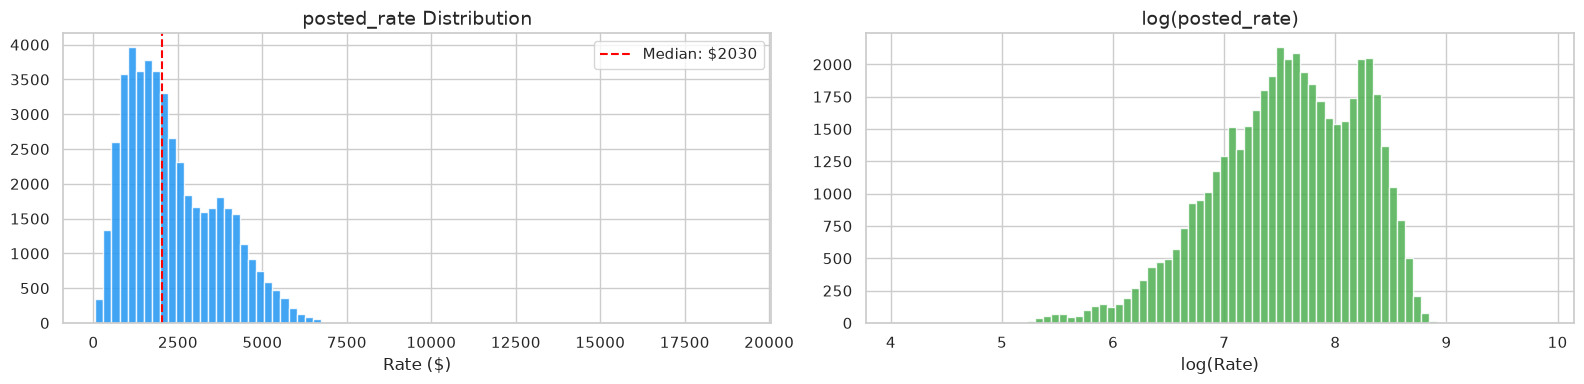

15

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].hist(df["posted_rate"], bins=80, color="#2196F3", edgecolor="white", alpha=0.85)
axes[0].set_title("posted_rate Distribution")
axes[0].set_xlabel("Rate ($)")
axes[0].axvline(df["posted_rate"].median(), color="red", ls="--", label=f"Median: ${df['posted_rate'].median():.0f}")
axes[0].legend()
axes[1].hist(np.log1p(df["posted_rate"]), bins=80, color="#4CAF50", edgecolor="white", alpha=0.85)
axes[1].set_title("log(posted_rate)")
axes[1].set_xlabel("log(Rate)")
plt.tight_layout(); plt.show(); plt.close("all"); gc.collect()

In [15]:
skew_raw = df["posted_rate"].skew()
skew_log = np.log1p(df["posted_rate"]).skew()
print(f"Skewness — raw: {skew_raw:.3f}, log: {skew_log:.3f}")
print(f"Kurtosis — raw: {df['posted_rate'].kurtosis():.3f}")

Skewness — raw: 1.139, log: -0.510
Kurtosis — raw: 3.715


### 4) Corelation Analysis


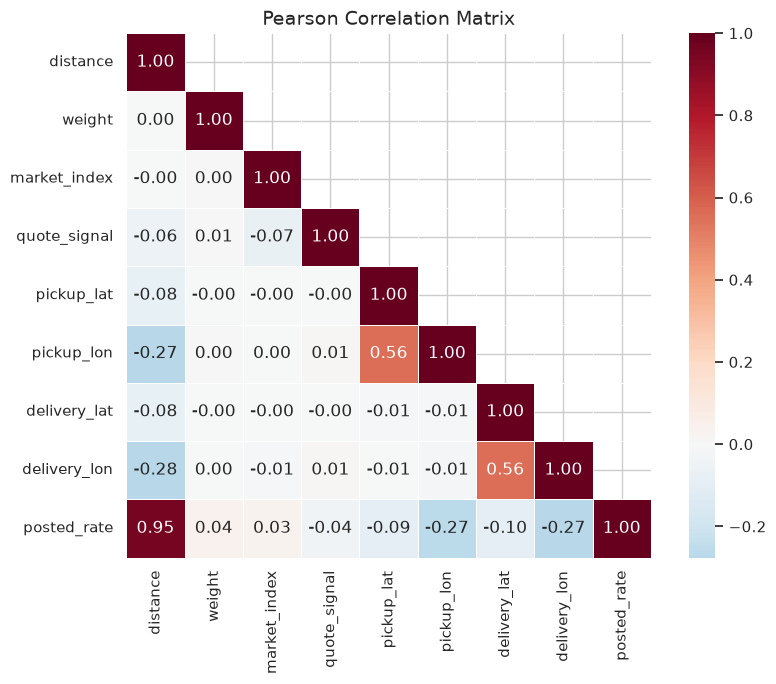

0

In [16]:
numeric_cols = ["distance", "weight", "market_index", "quote_signal",
                "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon", "posted_rate"]
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,square=True, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout(); plt.show(); plt.close("all"); gc.collect()

### Mutual Information

Mutual Information Scores (Higher is better):
distance        2.104577
pickup          0.239324
delivery        0.233557
delivery_lon    0.231892
pickup_lon      0.231712
pickup_lat      0.227166
delivery_lat    0.221502
quote_signal    0.179522
equipment       0.005663
weight          0.005561
market_index    0.000000
Name: MI Scores, dtype: float64


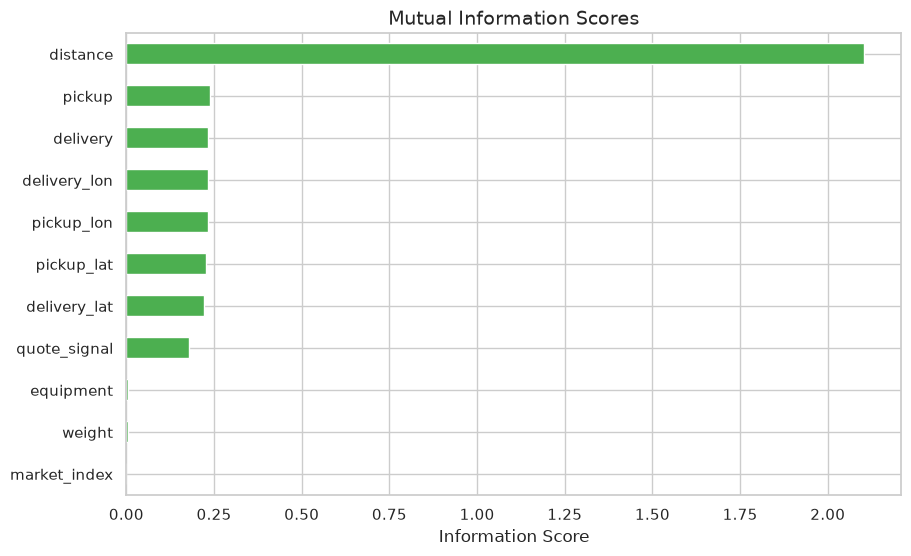

In [17]:
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt
import pandas as pd

mi_df = df.copy()

mi_df = mi_df.drop(columns=["load_id", "date"])


for col in ["pickup", "delivery", "equipment"]:
    mi_df[col] = mi_df[col].astype("category").cat.codes


X = mi_df.drop(columns=["posted_rate"])
y = mi_df["posted_rate"]


categorical_features = [X.columns.get_loc(col) for col in ["pickup", "delivery", "equipment"]]
mi_scores = mutual_info_regression(X, y, discrete_features=categorical_features, random_state=42)

mi_scores_series = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores_series = mi_scores_series.sort_values(ascending=False)


print("Mutual Information Scores (Higher is better):")
print(mi_scores_series)

plt.figure(figsize=(10, 6))
mi_scores_series.sort_values().plot.barh(color="#4CAF50")
plt.title("Mutual Information Scores")
plt.xlabel("Information Score")
plt.show()


### Features vs target Scatter Plots

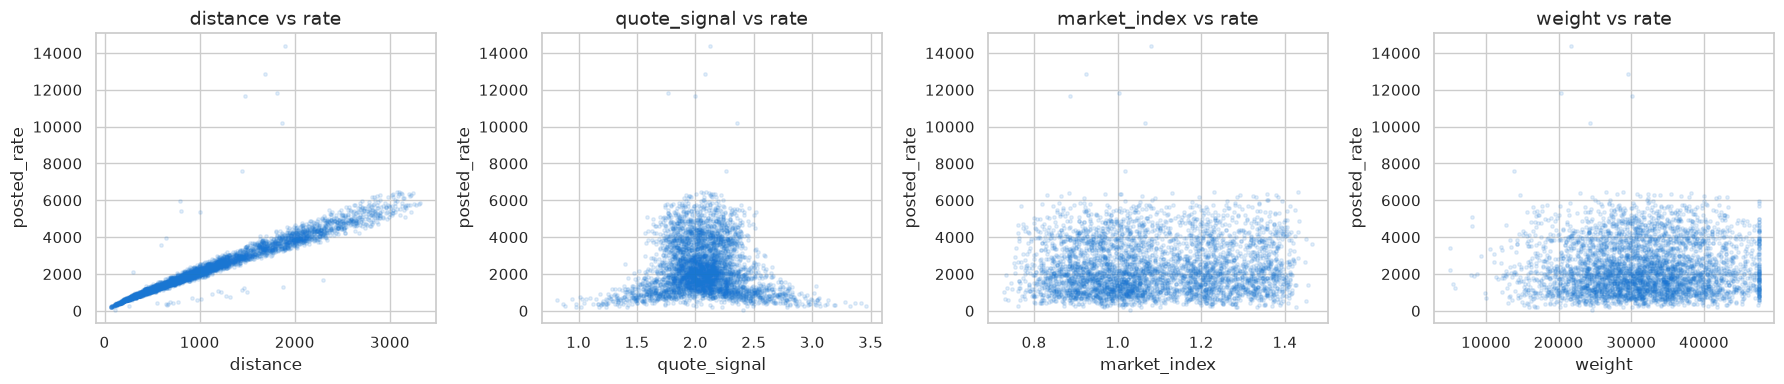

In [18]:
top_features = ["distance", "quote_signal", "market_index", "weight"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sample = df.sample(min(4000, len(df)), random_state=42)
for ax, feat in zip(axes, top_features):
    ax.scatter(sample[feat], sample["posted_rate"], alpha=0.12, s=6, color="#1976D2")
    ax.set_xlabel(feat); ax.set_ylabel("posted_rate"); ax.set_title(f"{feat} vs rate")
plt.tight_layout(); plt.show(); plt.close("all"); gc.collect()
del sample

### Temporal Analysis

              mean    median          std  count
month                                           
1      2240.006625  1915.060  1365.191903   4895
2      2267.330604  1993.200  1301.128664   4323
3      2358.479623  2021.715  1392.747888   5012
4      2367.696432  2045.795  1419.798415   4792
5      2405.304838  2065.350  1414.298513   4882
6      2473.578040  2117.980  1499.422828   4756
7      2395.119417  2058.805  1409.225248   4888
8      2325.165356  2017.060  1396.286081   4735
9      2389.345090  2056.675  1441.820237   4650
10     2362.118796  2035.900  1454.330237   4819


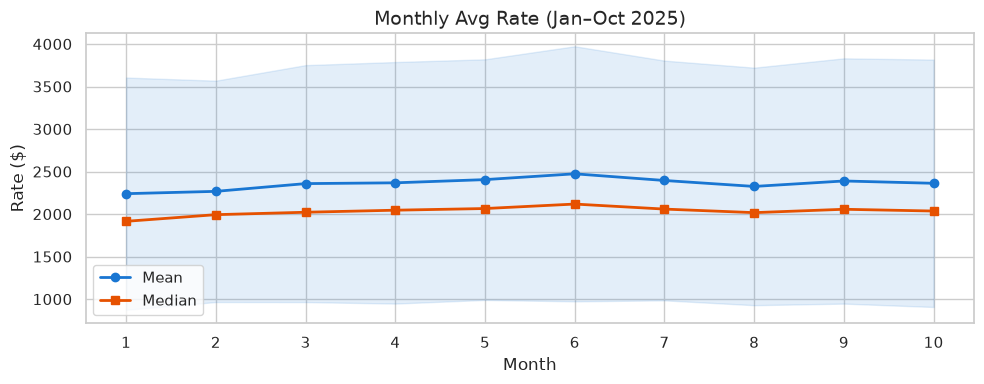

12

In [19]:
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["week"] = df["date"].dt.isocalendar().week.astype(int)

monthly = df.groupby("month")["posted_rate"].agg(["mean", "median", "std", "count"])
print(monthly)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly["mean"], marker="o", color="#1976D2", lw=2, label="Mean")
ax.plot(monthly.index, monthly["median"], marker="s", color="#E65100", lw=2, label="Median")
ax.fill_between(monthly.index, monthly["mean"] - monthly["std"], monthly["mean"] + monthly["std"], alpha=0.12, color="#1976D2")
ax.set_xlabel("Month"); ax.set_ylabel("Rate ($)"); ax.set_title("Monthly Avg Rate (Jan–Oct 2025)")
ax.set_xticks(range(1, 11)); ax.legend()
plt.tight_layout(); plt.show(); plt.close("all"); gc.collect()

### Lane Analysis

Top 15 most frequent lanes:
                                   mean  count
lane                                          
Lexington => Atlanta         560.106154     39
Columbia => Oklahoma City   2330.734615     39
Phoenix => Shreveport       3507.618462     39
Lexington => Kansas City    1042.474595     37
Fort Wayne => Philadelphia  1717.577027     37
Fort Wayne => Hartford      1938.657297     37
Richmond => Phoenix         5190.194595     37
Shreveport => Hartford      2867.768108     37
Lexington => Cincinnati      374.959444     36
Fort Wayne => Cincinnati     871.521111     36
Richmond => Oklahoma City   3159.483056     36
Hartford => Baton Rouge     3102.180571     35
Columbia => Montgomery       837.918857     35
Mobile => Phoenix           3804.664000     35
Oklahoma City => Columbia   2333.602857     35


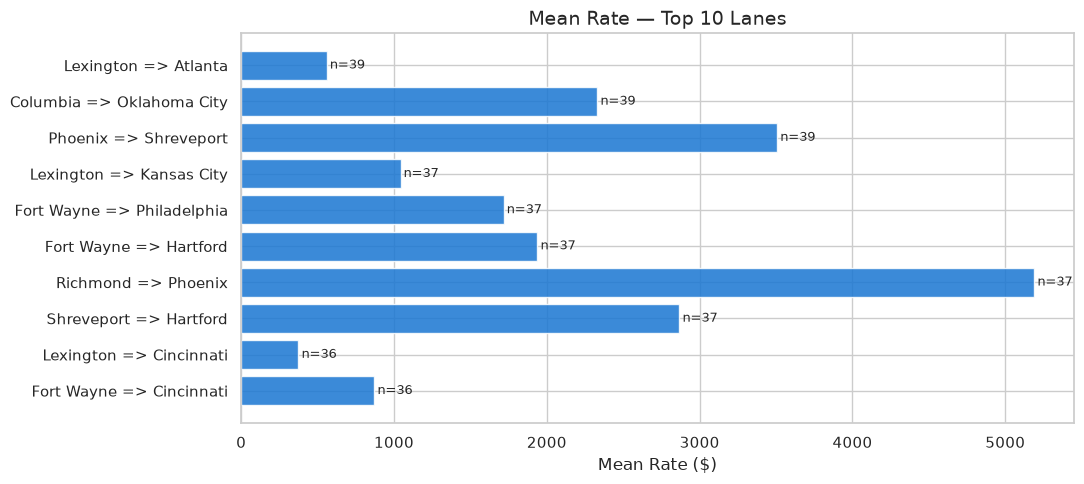

3273

In [20]:
df["lane"] = df["pickup"] + " => " + df["delivery"]
lane_stats = df.groupby("lane")["posted_rate"].agg(["mean", "count"]).sort_values("count", ascending=False)
print("Top 15 most frequent lanes:")
print(lane_stats.head(15))


top_lanes = lane_stats.head(10)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_lanes.index[::-1], top_lanes["mean"][::-1], color="#1976D2", alpha=0.85)
ax.set_xlabel("Mean Rate ($)"); ax.set_title("Mean Rate — Top 10 Lanes")
for bar, cnt in zip(bars, top_lanes["count"][::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, f'n={cnt}', va="center", fontsize=9)
plt.tight_layout(); plt.show(); plt.close("all"); gc.collect()